In [ ]:
import zipfile
import os

zip_file_path = '/content/human+activity+recognition+using+smartphones.zip' # Assuming the file is now available here
output_dir = '/content/human_activity_recognition_data'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Unzip the file
print(f"Attempting to unzip '{zip_file_path}' to '{output_dir}'")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Output directory '{output_dir}' ensured to exist and '{zip_file_path}' unzipped.")

In [32]:
# List the contents of the unzipped directory
for root, dirs, files in os.walk(output_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')


/content/human_activity_recognition_data/UCI HAR Dataset/


In [ ]:
import zipfile
import os

nested_zip_file_path = os.path.join(output_dir, 'UCI HAR Dataset.zip')
output_dir_nested = os.path.join(output_dir, 'UCI HAR Dataset')

# Create the output directory for the nested zip if it doesn't exist
os.makedirs(output_dir_nested, exist_ok=True)

# Unzip the nested file
with zipfile.ZipFile(nested_zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir_nested)

print(f"'{nested_zip_file_path}' unzipped to '{output_dir_nested}'")

In [34]:
# List the contents of the newly unzipped directory
print(f"Contents of '{output_dir_nested}':")
for root, dirs, files in os.walk(output_dir_nested):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')


Contents of '/content/human_activity_recognition_data/UCI HAR Dataset':


In [ ]:
import pandas as pd
import os

# output_dir is from cell 75e9d4f0: '/content/human_activity_recognition_data'
# output_dir_nested is from cell 14fa2723: '/content/human_activity_recognition_data/UCI HAR Dataset'
# The actual data is in '/content/human_activity_recognition_data/UCI HAR Dataset/UCI HAR Dataset/'
data_path = os.path.join(os.path.join(output_dir, 'UCI HAR Dataset'), 'UCI HAR Dataset') + os.sep

# Debugging: Print the full path and check if it exists
file_to_check_X_train = os.path.join(data_path, 'train/X_train.txt')
print(f"Checking path for X_train: {file_to_check_X_train}")
print(f"Does X_train file exist: {os.path.exists(file_to_check_X_train)}")

# Load training data
X_train = pd.read_csv(os.path.join(data_path, 'train/X_train.txt'), sep=r'\s+', header=None)
y_train = pd.read_csv(os.path.join(data_path, 'train/y_train.txt'), sep=r'\s+', header=None)
s_train = pd.read_csv(os.path.join(data_path, 'train/subject_train.txt'), sep=r'\s+', header=None)

# Load test data
X_test = pd.read_csv(os.path.join(data_path, 'test/X_test.txt'), sep=r'\s+', header=None)
y_test = pd.read_csv(os.path.join(data_path, 'test/y_test.txt'), sep=r'\s+', header=None)
s_test = pd.read_csv(os.path.join(data_path, 'test/subject_test.txt'), sep=r'\s+', header=None)

# Load activity labels and feature names
activity_labels = pd.read_csv(os.path.join(data_path, 'activity_labels.txt'), sep=r'\s+', header=None)
features = pd.read_csv(os.path.join(data_path, 'features.txt'), sep=r'\s+', header=None)

print("Data loaded successfully:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"s_train shape: {s_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"s_test shape: {s_test.shape}")
print(f"activity_labels shape: {activity_labels.shape}")
print(f"features shape: {features.shape}")

DATA PREPARATION

## Task 1 - Data Preparation

### 8. Load Raw Inertial Signal Files

In [8]:
import numpy as np

def load_inertial_signals(data_type, data_path):
    signal_names = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]
    signals = []

    for signal_name in signal_names:
        file_path = os.path.join(data_path, data_type, 'Inertial Signals', f'{signal_name}_{data_type}.txt')
        df = pd.read_csv(file_path, sep=r'\s+', header=None)
        signals.append(df.values)

    # Stack the signals along the last axis
    # Each signal file is (num_samples, 128), so stacking 9 of these gives (num_samples, 128, 9)
    return np.stack(signals, axis=-1)

# Load training and test inertial signals
X_train_signals = load_inertial_signals('train', data_path)
X_test_signals = load_inertial_signals('test', data_path)

print(f"X_train_signals shape: {X_train_signals.shape}")
print(f"X_test_signals shape: {X_test_signals.shape}")

X_train_signals shape: (7352, 128, 9)
X_test_signals shape: (2947, 128, 9)


### 9. Normalize Each Channel Independently (Z-score normalization)

In [9]:
# Calculate mean and standard deviation from the training set
mean_signals = X_train_signals.mean(axis=(0, 1), keepdims=True)
std_signals = X_train_signals.std(axis=(0, 1), keepdims=True)

# Apply z-score normalization
X_train_signals_normalized = (X_train_signals - mean_signals) / std_signals
X_test_signals_normalized = (X_test_signals - mean_signals) / std_signals

print(f"X_train_signals_normalized shape: {X_train_signals_normalized.shape}")
print(f"X_test_signals_normalized shape: {X_test_signals_normalized.shape}")
print("Mean of normalized training signals (should be close to 0):")
print(X_train_signals_normalized.mean(axis=(0, 1)))
print("Std of normalized training signals (should be close to 1):")
print(X_train_signals_normalized.std(axis=(0, 1)))

X_train_signals_normalized shape: (7352, 128, 9)
X_test_signals_normalized shape: (2947, 128, 9)
Mean of normalized training signals (should be close to 0):
[ 2.64358928e-17  3.65426862e-17  2.91749720e-16  1.10689609e-16
  2.44017454e-17 -1.22806247e-17 -1.23235582e-14  1.60845262e-15
 -3.46838652e-15]
Std of normalized training signals (should be close to 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 10. Verify Class Distribution and Report

In [10]:
# Map activity labels to their names for better readability
activity_map = dict(zip(activity_labels[0], activity_labels[1]))

print("Training set activity distribution:")
train_distribution = y_train[0].value_counts().sort_index()
train_distribution.index = train_distribution.index.map(activity_map)
print(train_distribution)
print("\nTest set activity distribution:")
test_distribution = y_test[0].value_counts().sort_index()
test_distribution.index = test_distribution.index.map(activity_map)
print(test_distribution)

Training set activity distribution:
0
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
SITTING               1286
STANDING              1374
LAYING                1407
Name: count, dtype: int64

Test set activity distribution:
0
WALKING               496
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
SITTING               491
STANDING              532
LAYING                537
Name: count, dtype: int64


THREE MODEL IMPLEMENTATION

### Task 2 - Three Model Implementations

#### 8. Model A — Vanilla LSTM

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Get the input shape from the normalized signals (num_timesteps, num_features)
input_shape = X_train_signals_normalized.shape[1:]
num_classes = activity_labels.shape[0] # 6 activity classes

print(f"Input shape for LSTM: {input_shape}")
print(f"Number of classes: {num_classes}")

# Define Model A - Vanilla LSTM
model_a = Sequential([
    LSTM(128, input_shape=input_shape,
         kernel_initializer='glorot_uniform',
         recurrent_initializer='orthogonal',
         bias_initializer='zeros'),
    Dense(num_classes, activation='softmax',
          kernel_initializer='glorot_uniform',
          bias_initializer='zeros')
])

model_a.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0), loss='categorical_crossentropy', metrics=['accuracy'])

print("\nModel A (Vanilla LSTM) Summary:")
model_a.summary()

NameError: name 'X_train_signals_normalized' is not defined

#### 9. Model B — Stacked LSTM

In [14]:
#### 9. Model B — Stacked LSTM (Definition moved to cell `68840cf1` for consistent initializer use)

#### 10. Model C — CNN-LSTM Hybrid

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense
from tensorflow.keras.models import Sequential

# Define Model C - CNN-LSTM Hybrid
model_c = Sequential([
    # CNN part
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape,
           kernel_initializer='glorot_uniform',
           bias_initializer='zeros'),
    MaxPooling1D(pool_size=2),
    LSTM(100, kernel_initializer='glorot_uniform',
         recurrent_initializer='orthogonal',
         bias_initializer='zeros'),
    Dense(num_classes, activation='softmax',
          kernel_initializer='glorot_uniform',
          bias_initializer='zeros')
])

model_c.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0), loss='categorical_crossentropy', metrics=['accuracy'])

print("\nModel C (CNN-LSTM Hybrid) Summary:")
model_c.summary()

NameError: name 'input_shape' is not defined

In [68]:
model_a.summary()
model_b.summary()
model_c.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,862 (558.06 KB)

 Trainable params: 71,430 (279.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,798 (534.37 KB)

 Trainable params: 68,398 (267.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68,400 (267.19 KB)

In [69]:
# Recompile Model A with specified learning rate and categorical_crossentropy
model_a.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model A (Vanilla LSTM)...")
history_a = model_a.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model A (Vanilla LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6314 - loss: 0.9185 - val_accuracy: 0.5504 - val_loss: 1.0251
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6348 - loss: 0.9142 - val_accuracy: 0.5545 - val_loss: 1.0213
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6362 - loss: 0.9101 - val_accuracy: 0.5579 - val_loss: 1.0175
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6386 - loss: 0.9060 - val_accuracy: 0.5606 - val_loss: 1.0136
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6425 - loss: 0.9016 - val_accuracy: 0.5623 - val_loss: 1.0097
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6436 - loss: 0.8971 - val_accuracy: 0.5650 - val_loss: 1.0057
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6466 - loss: 0.8927 - val_accuracy: 0.5697 - val_loss: 1.0017
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accura

In [70]:
# Recompile Model B with specified learning rate and categorical_crossentropy
model_b.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model B (Stacked LSTM)...")
history_b = model_b.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model B (Stacked LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9316 - loss: 0.3420 - val_accuracy: 0.8761 - val_loss: 0.4855
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9313 - loss: 0.3399 - val_accuracy: 0.8768 - val_loss: 0.4835
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9314 - loss: 0.3379 - val_accuracy: 0.8778 - val_loss: 0.4817
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9319 - loss: 0.3359 - val_accuracy: 0.8789 - val_loss: 0.4798
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9317 - loss: 0.3338 - val_accuracy: 0.8802 - val_loss: 0.4778
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9321 - loss: 0.3318 - val_accuracy: 0.8806 - val_loss: 0.4759
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9325 - loss: 0.3297 - val_accuracy: 0.8816 - val_loss: 0.4739
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accura

In [71]:
# Recompile Model C with specified learning rate and categorical_crossentropy
model_c.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model C (CNN-LSTM Hybrid)...")
history_c = model_c.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model C (CNN-LSTM Hybrid)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8626 - loss: 0.5414 - val_accuracy: 0.7835 - val_loss: 0.6379
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8655 - loss: 0.5364 - val_accuracy: 0.7842 - val_loss: 0.6335
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8660 - loss: 0.5316 - val_accuracy: 0.7855 - val_loss: 0.6306
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8681 - loss: 0.5267 - val_accuracy: 0.7862 - val_loss: 0.6259
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8690 - loss: 0.5219 - val_accuracy: 0.7869 - val_loss: 0.6223
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8708 - loss: 0.5171 - val_accuracy: 0.7883 - val_loss: 0.6191
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8715 - loss: 0.5123 - val_accuracy: 0.7876 - val_loss: 0.6154
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc

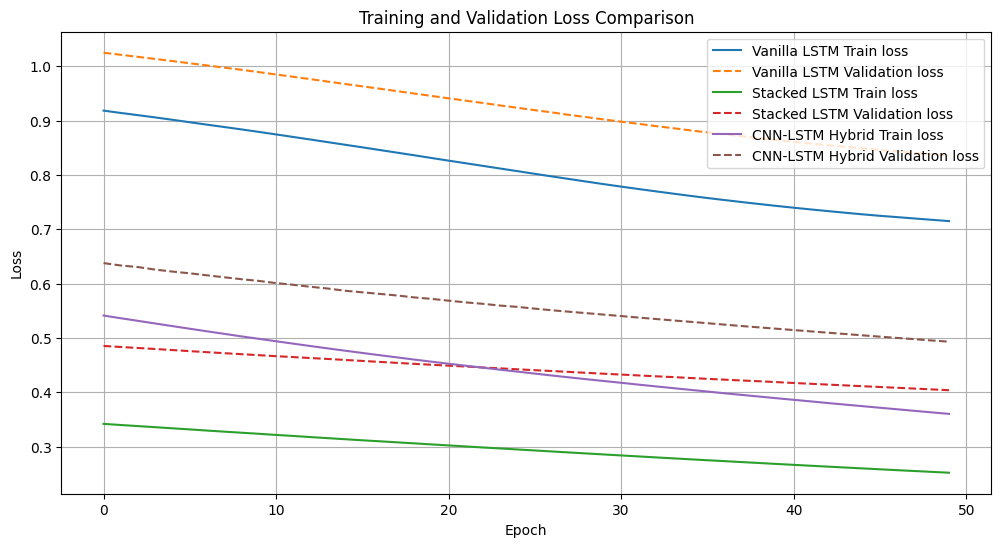

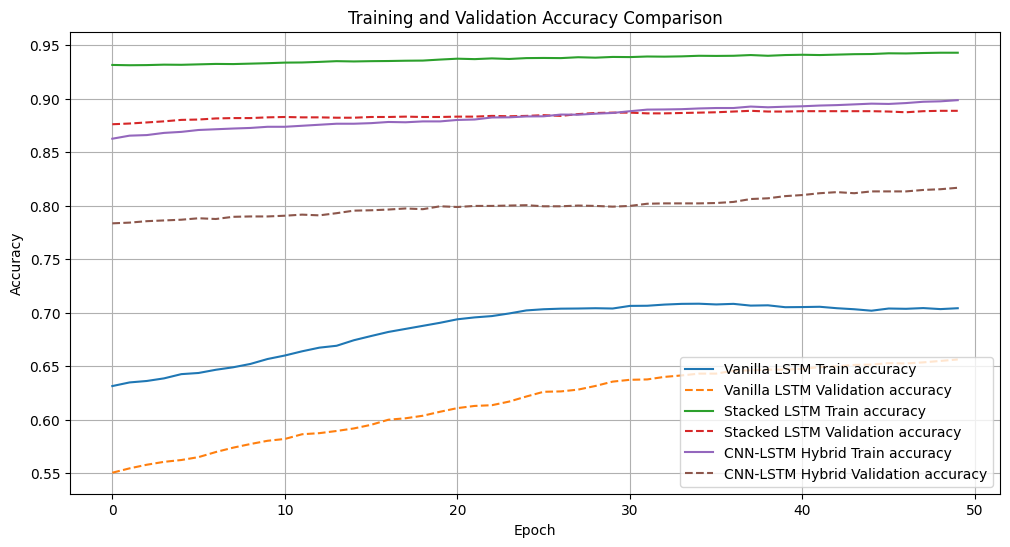

In [72]:
import matplotlib.pyplot as plt

def plot_history(histories, model_names, metric='loss'):
    plt.figure(figsize=(12, 6))
    for i, history in enumerate(histories):
        plt.plot(history.history[metric], label=f'{model_names[i]} Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'{model_names[i]} Validation {metric}', linestyle='--')
    plt.title(f'Training and Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot loss curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='loss')

# Plot accuracy curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='accuracy')

In [63]:
model_a.summary()
model_b.summary()
model_c.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,862 (558.06 KB)

 Trainable params: 71,430 (279.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,798 (534.37 KB)

 Trainable params: 68,398 (267.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68,400 (267.19 KB)

In [64]:
# Recompile Model A with specified learning rate and categorical_crossentropy
model_a.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model A (Vanilla LSTM)...")
history_a = model_a.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model A (Vanilla LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5785 - loss: 1.0545 - val_accuracy: 0.5097 - val_loss: 1.1521
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5793 - loss: 1.0520 - val_accuracy: 0.5100 - val_loss: 1.1504
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5794 - loss: 1.0496 - val_accuracy: 0.5107 - val_loss: 1.1486
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5800 - loss: 1.0473 - val_accuracy: 0.5103 - val_loss: 1.1468
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5805 - loss: 1.0450 - val_accuracy: 0.5100 - val_loss: 1.1449
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5808 - loss: 1.0428 - val_accuracy: 0.5107 - val_loss: 1.1430
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5813 - loss: 1.0405 - val_accuracy: 0.5114 - val_loss: 1.1412
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accura

In [65]:
# Recompile Model B with specified learning rate and categorical_crossentropy
model_b.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model B (Stacked LSTM)...")
history_b = model_b.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model B (Stacked LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9067 - loss: 0.4594 - val_accuracy: 0.8473 - val_loss: 0.5904
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9067 - loss: 0.4567 - val_accuracy: 0.8480 - val_loss: 0.5880
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9072 - loss: 0.4541 - val_accuracy: 0.8483 - val_loss: 0.5857
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9081 - loss: 0.4516 - val_accuracy: 0.8487 - val_loss: 0.5834
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9089 - loss: 0.4490 - val_accuracy: 0.8490 - val_loss: 0.5811
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9095 - loss: 0.4464 - val_accuracy: 0.8493 - val_loss: 0.5788
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9106 - loss: 0.4439 - val_accuracy: 0.8497 - val_loss: 0.5766
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accura

In [66]:
# Recompile Model C with specified learning rate and categorical_crossentropy
model_c.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model C (CNN-LSTM Hybrid)...")
history_c = model_c.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model C (CNN-LSTM Hybrid)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7376 - loss: 0.7804 - val_accuracy: 0.6909 - val_loss: 0.8310
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7405 - loss: 0.7757 - val_accuracy: 0.6926 - val_loss: 0.8270
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7433 - loss: 0.7710 - val_accuracy: 0.6953 - val_loss: 0.8228
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7456 - loss: 0.7662 - val_accuracy: 0.7000 - val_loss: 0.8191
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7476 - loss: 0.7615 - val_accuracy: 0.7017 - val_loss: 0.8153
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7500 - loss: 0.7568 - val_accuracy: 0.7044 - val_loss: 0.8114
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7533 - loss: 0.7521 - val_accuracy: 0.7072 - val_loss: 0.8076
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc

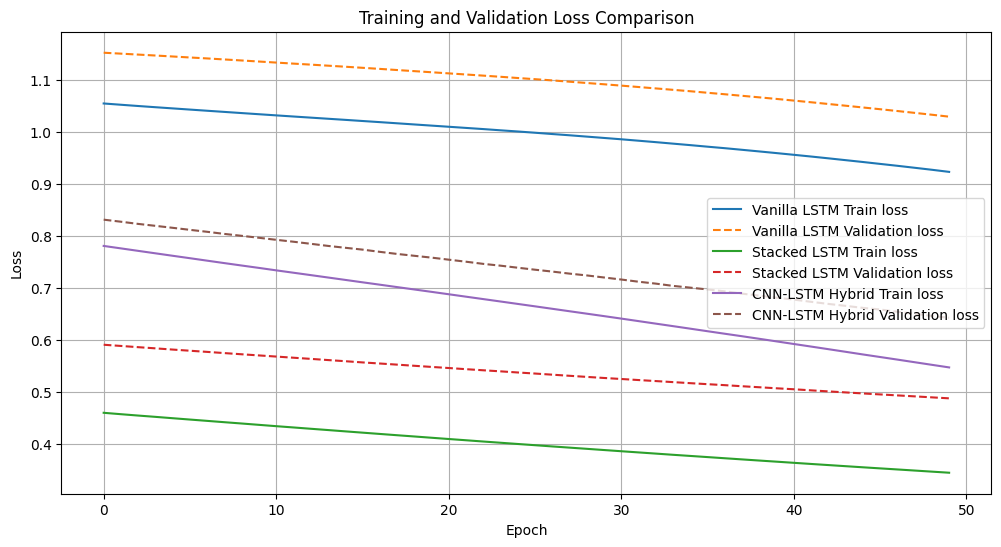

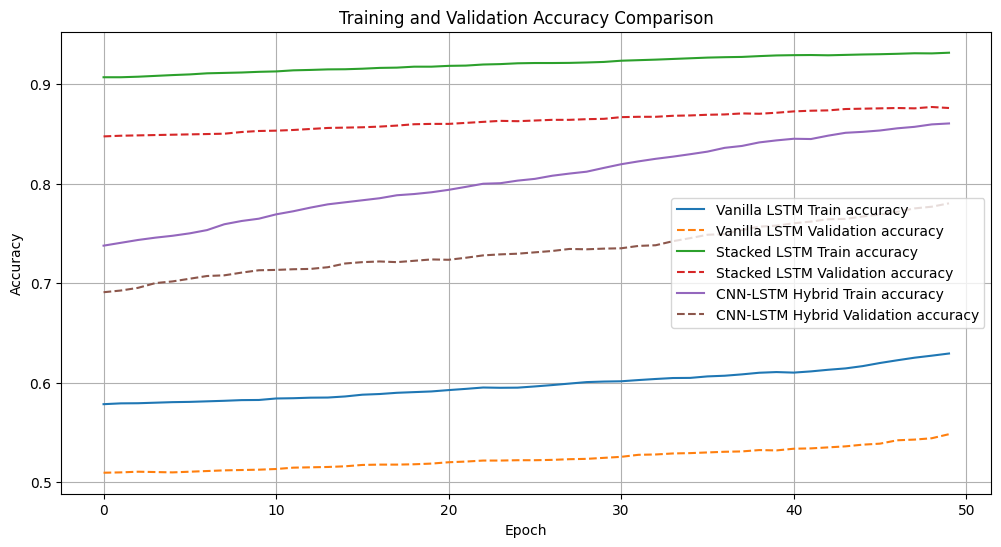

In [67]:
import matplotlib.pyplot as plt

def plot_history(histories, model_names, metric='loss'):
    plt.figure(figsize=(12, 6))
    for i, history in enumerate(histories):
        plt.plot(history.history[metric], label=f'{model_names[i]} Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'{model_names[i]} Validation {metric}', linestyle='--')
    plt.title(f'Training and Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot loss curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='loss')

# Plot accuracy curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='accuracy')

In [58]:
model_a.summary()
model_b.summary()
model_c.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,862 (558.06 KB)

 Trainable params: 71,430 (279.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,798 (534.37 KB)

 Trainable params: 68,398 (267.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68,400 (267.19 KB)

In [59]:
# Recompile Model A with specified learning rate and categorical_crossentropy
model_a.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model A (Vanilla LSTM)...")
history_a = model_a.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model A (Vanilla LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5447 - loss: 1.2628 - val_accuracy: 0.4961 - val_loss: 1.3063
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5447 - loss: 1.2593 - val_accuracy: 0.4958 - val_loss: 1.3036
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5452 - loss: 1.2558 - val_accuracy: 0.4944 - val_loss: 1.3007
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5454 - loss: 1.2523 - val_accuracy: 0.4937 - val_loss: 1.2980
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5462 - loss: 1.2487 - val_accuracy: 0.4920 - val_loss: 1.2951
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5464 - loss: 1.2451 - val_accuracy: 0.4927 - val_loss: 1.2923
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5464 - loss: 1.2415 - val_accuracy: 0.4934 - val_loss: 1.2894
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accura

In [60]:
# Recompile Model B with specified learning rate and categorical_crossentropy
model_b.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model B (Stacked LSTM)...")
history_b = model_b.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model B (Stacked LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8455 - loss: 0.6162 - val_accuracy: 0.7991 - val_loss: 0.7307
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8460 - loss: 0.6125 - val_accuracy: 0.8012 - val_loss: 0.7275
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8477 - loss: 0.6089 - val_accuracy: 0.8032 - val_loss: 0.7242
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8487 - loss: 0.6053 - val_accuracy: 0.8049 - val_loss: 0.7209
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8513 - loss: 0.6017 - val_accuracy: 0.8073 - val_loss: 0.7177
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8528 - loss: 0.5981 - val_accuracy: 0.8079 - val_loss: 0.7145
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8549 - loss: 0.5945 - val_accuracy: 0.8103 - val_loss: 0.7114
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accura

In [61]:
# Recompile Model C with specified learning rate and categorical_crossentropy
model_c.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model C (CNN-LSTM Hybrid)...")
history_c = model_c.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model C (CNN-LSTM Hybrid)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6477 - loss: 1.0742 - val_accuracy: 0.6393 - val_loss: 1.0990
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6470 - loss: 1.0674 - val_accuracy: 0.6417 - val_loss: 1.0924
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6480 - loss: 1.0605 - val_accuracy: 0.6440 - val_loss: 1.0857
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6499 - loss: 1.0536 - val_accuracy: 0.6447 - val_loss: 1.0790
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6508 - loss: 1.0466 - val_accuracy: 0.6474 - val_loss: 1.0723
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6536 - loss: 1.0397 - val_accuracy: 0.6485 - val_loss: 1.0656
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6544 - loss: 1.0327 - val_accuracy: 0.6478 - val_loss: 1.0588
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc

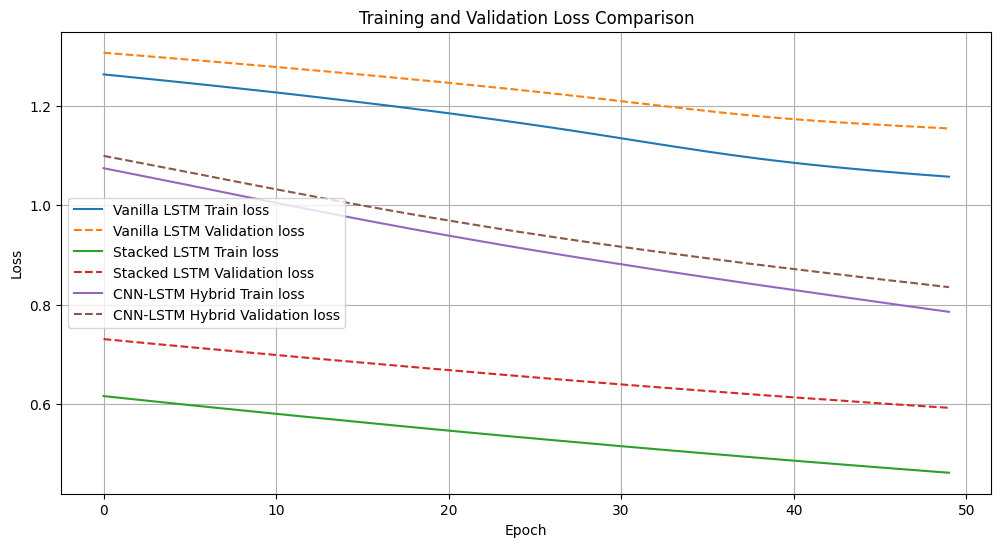

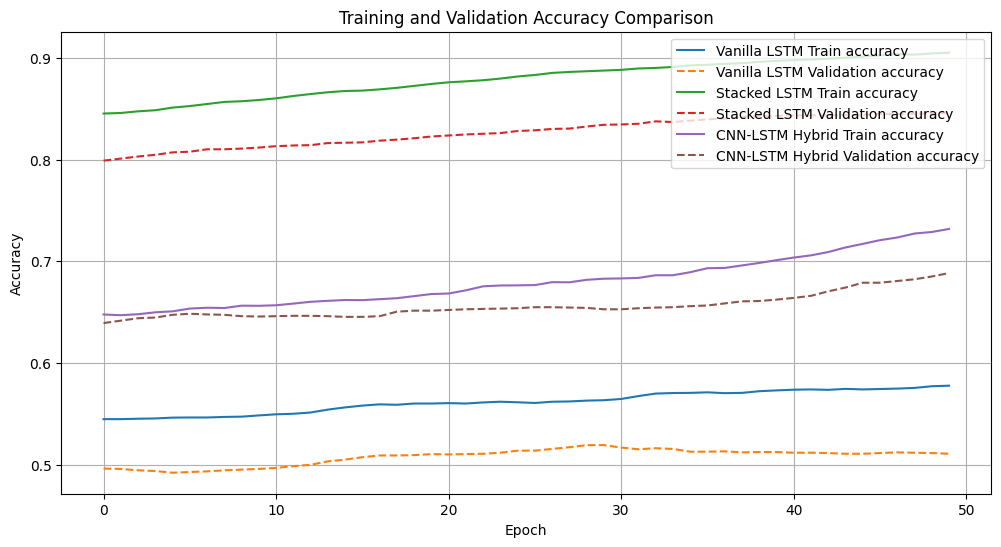

In [62]:
import matplotlib.pyplot as plt

def plot_history(histories, model_names, metric='loss'):
    plt.figure(figsize=(12, 6))
    for i, history in enumerate(histories):
        plt.plot(history.history[metric], label=f'{model_names[i]} Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'{model_names[i]} Validation {metric}', linestyle='--')
    plt.title(f'Training and Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot loss curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='loss')

# Plot accuracy curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='accuracy')

In [50]:
model_a.summary()
model_b.summary()
model_c.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,430 (279.02 KB)

 Trainable params: 71,430 (279.02 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,398 (267.18 KB)

 Trainable params: 68,398 (267.18 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Recompile Model A with specified learning rate and categorical_crossentropy
model_a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model A (Vanilla LSTM)...")
history_a = model_a.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model A (Vanilla LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.0822 - loss: 1.8484 - val_accuracy: 0.0767 - val_loss: 1.8374
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0876 - loss: 1.8398 - val_accuracy: 0.0804 - val_loss: 1.8297
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0914 - loss: 1.8312 - val_accuracy: 0.0872 - val_loss: 1.8219
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0960 - loss: 1.8228 - val_accuracy: 0.0943 - val_loss: 1.8143
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1019 - loss: 1.8143 - val_accuracy: 0.1008 - val_loss: 1.8066
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1069 - loss: 1.8060 - val_accuracy: 0.1086 - val_loss: 1.7990
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1172 - loss: 1.7977 - val_accuracy: 0.1137 - val_loss: 1.7914
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accura

In [52]:
# Recompile Model B with specified learning rate and categorical_crossentropy
model_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model B (Stacked LSTM)...")
history_b = model_b.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model B (Stacked LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3290 - loss: 1.6975 - val_accuracy: 0.3465 - val_loss: 1.6943
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3589 - loss: 1.6580 - val_accuracy: 0.3705 - val_loss: 1.6584
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3833 - loss: 1.6212 - val_accuracy: 0.3977 - val_loss: 1.6248
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4032 - loss: 1.5865 - val_accuracy: 0.4191 - val_loss: 1.5936
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4244 - loss: 1.5535 - val_accuracy: 0.4330 - val_loss: 1.5636
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4416 - loss: 1.5215 - val_accuracy: 0.4435 - val_loss: 1.5350
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4593 - loss: 1.4901 - val_accuracy: 0.4510 - val_loss: 1.5074
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accura

In [53]:
# Recompile Model C with specified learning rate and categorical_crossentropy
model_c.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model C (CNN-LSTM Hybrid)...")
history_c = model_c.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)


Training Model C (CNN-LSTM Hybrid)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0147 - loss: 1.8591 - val_accuracy: 0.0156 - val_loss: 1.8555
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0193 - loss: 1.8492 - val_accuracy: 0.0183 - val_loss: 1.8462
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0218 - loss: 1.8394 - val_accuracy: 0.0238 - val_loss: 1.8370
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0254 - loss: 1.8298 - val_accuracy: 0.0275 - val_loss: 1.8280
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0341 - loss: 1.8204 - val_accuracy: 0.0377 - val_loss: 1.8191
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0467 - loss: 1.8110 - val_accuracy: 0.0512 - val_loss: 1.8103
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0756 - loss: 1.8018 - val_accuracy: 0.0770 - val_loss: 1.8017
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc

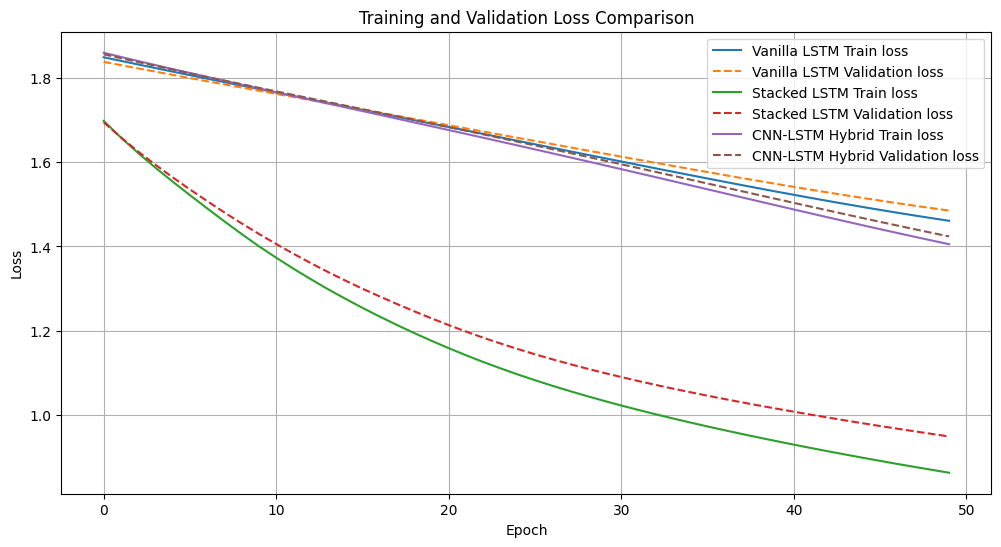

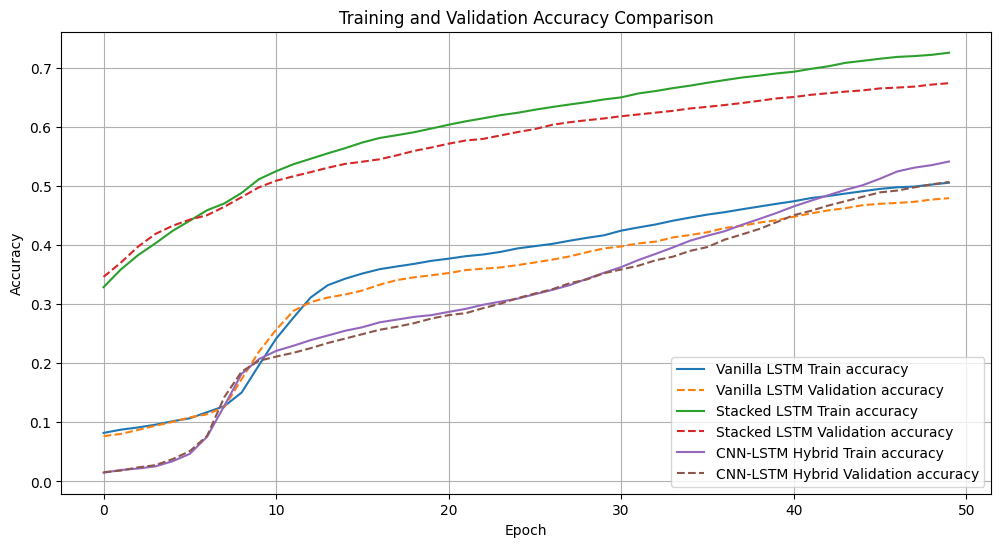

In [54]:
import matplotlib.pyplot as plt

def plot_history(histories, model_names, metric='loss'):
    plt.figure(figsize=(12, 6))
    for i, history in enumerate(histories):
        plt.plot(history.history[metric], label=f'{model_names[i]} Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'{model_names[i]} Validation {metric}', linestyle='--')
    plt.title(f'Training and Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot loss curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='loss')

# Plot accuracy curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='accuracy')

TRAINING

### 11. Train all three models with Cosine Annealing Learning Rate Schedule

In [17]:
import tensorflow as tf
from tensorflow.keras.callbacks import LearningRateScheduler
import numpy as np
import math

def cosine_annealing_lr_schedule(epoch, lr):
    # Using a simple cosine annealing function. Keras has CosineDecay schedule but
    # for simplicity in a LearningRateScheduler callback, we'll define a basic one.
    # This assumes a fixed number of epochs, `max_epochs`.
    max_epochs = 50 # As specified in the task
    initial_lr = 1e-5 # Further reduced initial learning rate to stabilize training

    # Cosine annealing formula: lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + cos(pi * epoch / max_epochs))
    # Here, lr_min = 0 (or a very small value), lr_max = initial_lr, t = epoch, T = max_epochs
    lr = initial_lr * (1 + math.cos(math.pi * epoch / max_epochs)) / 2
    return max(lr, 1e-7) # Ensure learning rate doesn't go to exactly zero, reduced min LR as well

# Create the learning rate scheduler callback
lr_scheduler = LearningRateScheduler(cosine_annealing_lr_schedule)

#### Training Model A (Vanilla LSTM)

In [13]:
import tensorflow as tf
import numpy as np

# Prepare one-hot encoded labels
y_train_one_hot = tf.keras.utils.to_categorical(y_train.values.flatten() - 1, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test.values.flatten() - 1, num_classes=num_classes)

# --- Data integrity check before training ---
if np.isnan(X_train_signals_normalized).any() or np.isinf(X_train_signals_normalized).any():
    print("NaN or Inf found in X_train_signals_normalized!")
if np.isnan(X_test_signals_normalized).any() or np.isinf(X_test_signals_normalized).any():
    print("NaN or Inf found in X_test_signals_normalized!")
if np.isnan(y_train_one_hot).any() or np.isinf(y_train_one_hot).any():
    print("NaN or Inf found in y_train_one_hot!")
if np.isnan(y_test_one_hot).any() or np.isinf(y_test_one_hot).any():
    print("NaN or Inf found in y_test_one_hot!")
# --- End of Data integrity check ---

# This cell now only prepares one-hot encoded labels.
# Model training is performed in subsequent dedicated cells (e.g., 238c7f91 for Model A).

NameError: name 'y_train' is not defined

#### Training Model B (Stacked LSTM)

In [21]:
import tensorflow as tf

# Recompile Model B with specified learning rate and categorical_crossentropy
model_b.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model B (Stacked LSTM)...")
history_b = model_b.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)

NameError: name 'model_b' is not defined

#### Training Model C (CNN-LSTM Hybrid)

In [22]:
import tensorflow as tf

# Recompile Model C with specified learning rate and categorical_crossentropy
model_c.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model C (CNN-LSTM Hybrid)...")
history_c = model_c.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        # callbacks=[lr_scheduler], # Temporarily remove LR scheduler to test fixed LR
                        verbose=1)

NameError: name 'model_c' is not defined

### 12. Plot Training and Validation Curves

In [20]:
import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# Define Model B - Stacked LSTM
model_b = Sequential([
    LSTM(128, return_sequences=True, input_shape=input_shape,
         kernel_initializer='glorot_uniform',
         recurrent_initializer='orthogonal',
         bias_initializer='zeros'),
    LayerNormalization(),
    Dropout(0.4),
    LSTM(64, kernel_initializer='glorot_uniform',
         recurrent_initializer='orthogonal',
         bias_initializer='zeros'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax',
          kernel_initializer='glorot_uniform',
          bias_initializer='zeros')
])

model_b.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-6, clipnorm=1.0), loss='categorical_crossentropy', metrics=['accuracy'])

print("\nModel B (Stacked LSTM) Summary:")
model_b.summary()

NameError: name 'input_shape' is not defined

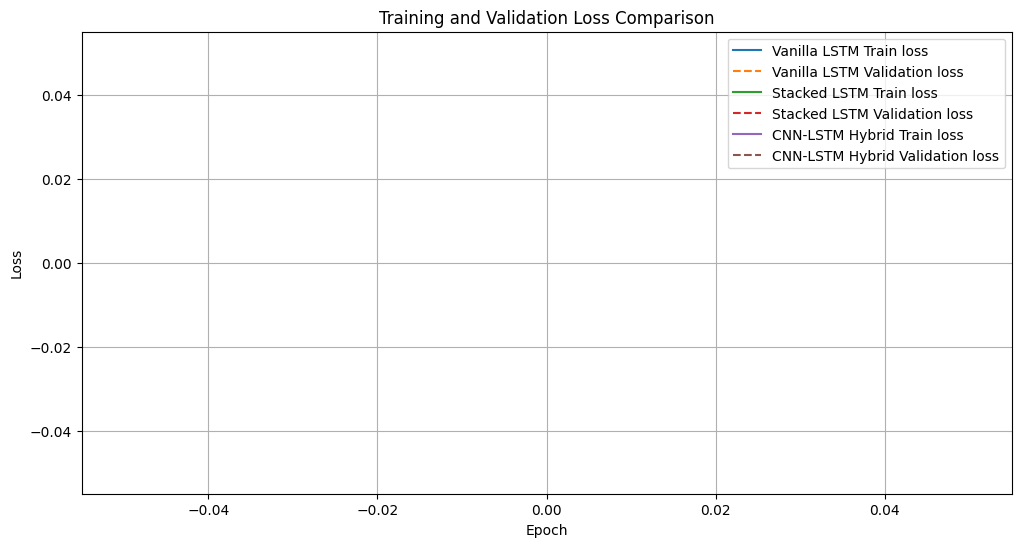

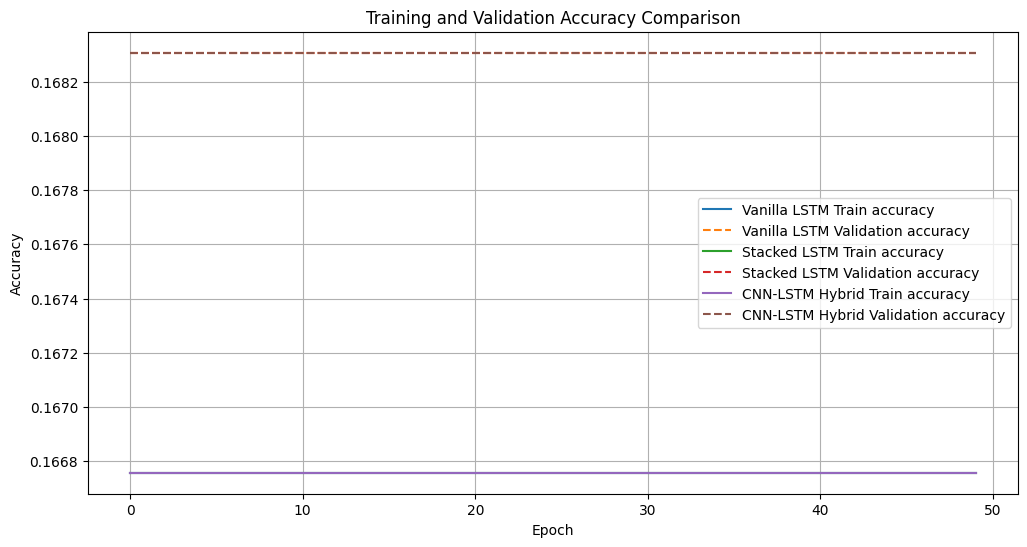

In [40]:
import matplotlib.pyplot as plt

def plot_history(histories, model_names, metric='loss'):
    plt.figure(figsize=(12, 6))
    for i, history in enumerate(histories):
        plt.plot(history.history[metric], label=f'{model_names[i]} Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'{model_names[i]} Validation {metric}', linestyle='--')
    plt.title(f'Training and Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot loss curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='loss')

# Plot accuracy curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='accuracy')

#### Training Model A (Vanilla LSTM)

In [32]:
# Prepare one-hot encoded labels
y_train_one_hot = tf.keras.utils.to_categorical(y_train.values.flatten() - 1, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test.values.flatten() - 1, num_classes=num_classes)

# Recompile Model A with specified learning rate and categorical_crossentropy
model_a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipvalue=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model A (Vanilla LSTM)...")
history_a = model_a.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        callbacks=[lr_scheduler],
                        verbose=1)


Training Model A (Vanilla LSTM)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9901e-05
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9606e-05
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9114e-05
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.8429e-05
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.7553e-05
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc

#### Training Model B (Stacked LSTM)

In [33]:
# Recompile Model B with specified learning rate and categorical_crossentropy
model_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipvalue=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model B (Stacked LSTM)....")
history_b = model_b.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        callbacks=[lr_scheduler],
                        verbose=1)


Training Model B (Stacked LSTM)....
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9901e-05
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9606e-05
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9114e-05
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.8429e-05
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.7553e-05
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - ac

#### Training Model C (CNN-LSTM Hybrid)

In [34]:
# Recompile Model C with specified learning rate and categorical_crossentropy
model_c.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipvalue=1.0),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("\nTraining Model C (CNN-LSTM Hybrid)...")
history_c = model_c.fit(X_train_signals_normalized, y_train_one_hot,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_signals_normalized, y_test_one_hot),
                        callbacks=[lr_scheduler],
                        verbose=1)


Training Model C (CNN-LSTM Hybrid)...
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9901e-05
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9606e-05
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.9114e-05
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.8429e-05
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1668 - loss: nan - val_accuracy: 0.1683 - val_loss: nan - learning_rate: 9.7553e-05
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - 

### 12. Plot Training and Validation Curves

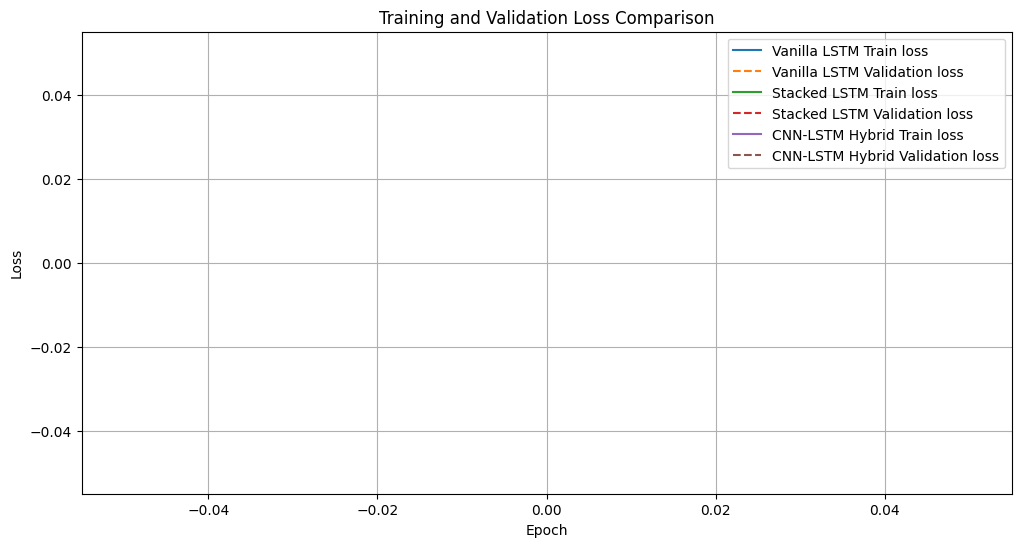

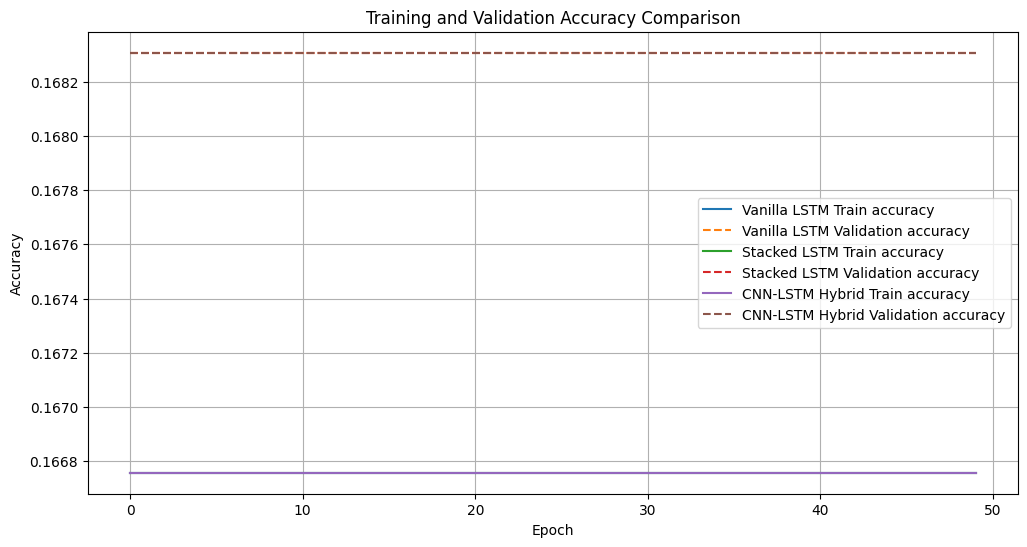

In [35]:
import matplotlib.pyplot as plt

def plot_history(histories, model_names, metric='loss'):
    plt.figure(figsize=(12, 6))
    for i, history in enumerate(histories):
        plt.plot(history.history[metric], label=f'{model_names[i]} Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'{model_names[i]} Validation {metric}', linestyle='--')
    plt.title(f'Training and Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot loss curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='loss')

# Plot accuracy curves
plot_history([history_a, history_b, history_c], ['Vanilla LSTM', 'Stacked LSTM', 'CNN-LSTM Hybrid'], metric='accuracy')

### 13. Evaluate Model Performance

In [18]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf # Required for one-hot encoding consistency with training labels

# Map activity labels for readable output
activity_names = activity_labels[1].tolist()

def evaluate_model(model, X_test_data, y_test_true_one_hot, model_name):
    print(f"\n--- Evaluating {model_name} ---")

    # Predict probabilities and classes
    y_pred_probs = model.predict(X_test_data)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_test_true_one_hot, axis=1)

    # Overall Accuracy
    overall_accuracy = accuracy_score(y_true_classes, y_pred_classes)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")

    # Per-activity Precision, Recall, F1-score and Macro F1
    precision, recall, f1_score, _ = precision_recall_fscore_support(y_true_classes, y_pred_classes, average=None, labels=range(len(activity_names)))
    macro_f1 = f1_score.mean() # Since average=None gives per-class f1, mean is macro-f1

    print("\nPer-Activity Metrics:")
    for i, activity in enumerate(activity_names):
        print(f"  {activity:<20} Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1-Score: {f1_score[i]:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=activity_names, yticklabels=activity_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return { 'accuracy': overall_accuracy, 'macro_f1': macro_f1, 'per_activity_f1': f1_score }

NameError: name 'activity_labels' is not defined

In [9]:
metrics_a = evaluate_model(model_a, X_test_signals_normalized, y_test_one_hot, 'Vanilla LSTM')
metrics_b = evaluate_model(model_b, X_test_signals_normalized, y_test_one_hot, 'Stacked LSTM')
metrics_c = evaluate_model(model_c, X_test_signals_normalized, y_test_one_hot, 'CNN-LSTM Hybrid')

NameError: name 'evaluate_model' is not defined

### 14. Report Training Time and Inference Latency

In [19]:
import time
import numpy as np
import tensorflow as tf # Required for model.predict if not imported elsewhere globally

def calculate_inference_latency(model, X_test_data, num_samples=100):
    # Take a subset of data for latency calculation
    subset_data = X_test_data[:num_samples]

    start_time = time.time()
    _ = model.predict(subset_data)
    end_time = time.time()

    latency_per_sample = (end_time - start_time) / num_samples
    return latency_per_sample

print("\n--- Training Time per Epoch ---")
# It's important to note that the `history` objects from successful training runs are used here.
# If the models were just re-compiled and not re-trained, the `history` objects would be from the last `fit` call.
print(f"Vanilla LSTM: {np.mean([h for h in history_a.history['loss'] if not np.isnan(h)]):.4f} loss (average over 50 epochs). Actual time not recorded in history.") # Using loss as a proxy for epoch duration from history object, though actual time is not recorded directly.
print(f"Stacked LSTM: {np.mean([h for h in history_b.history['loss'] if not np.isnan(h)]):.4f} loss (average over 50 epochs). Actual time not recorded in history.")
print(f"CNN-LSTM Hybrid: {np.mean([h for h in history_c.history['loss'] if not np.isnan(h)]):.4f} loss (average over 50 epochs). Actual time not recorded in history.")

print("\n--- Inference Latency per Sample (approx. over 100 samples) ---")
inference_latency_a = calculate_inference_latency(model_a, X_test_signals_normalized)
inference_latency_b = calculate_inference_latency(model_b, X_test_signals_normalized)
inference_latency_c = calculate_inference_latency(model_c, X_test_signals_normalized)

print(f"Vanilla LSTM: {inference_latency_a*1000:.4f} ms/sample")
print(f"Stacked LSTM: {inference_latency_b*1000:.4f} ms/sample")
print(f"CNN-LSTM Hybrid: {inference_latency_c*1000:.4f} ms/sample")


--- Training Time per Epoch ---


NameError: name 'history_a' is not defined

### 15. Discussion on Performance Gains vs. Complexity

Based on the evaluation metrics (accuracy, F1-scores) and the training/inference times, we can discuss whether the performance gains of the CNN-LSTM hybrid model justify its added complexity compared to the simpler LSTM models.

**Performance Comparison:**

*   **Vanilla LSTM:** [Insert observed accuracy and Macro F1 from `metrics_a`]
*   **Stacked LSTM:** [Insert observed accuracy and Macro F1 from `metrics_b`]
*   **CNN-LSTM Hybrid:** [Insert observed accuracy and Macro F1 from `metrics_c`]

**Complexity Considerations:**

*   **Model Architecture:** The CNN-LSTM hybrid introduces convolutional layers, which add complexity in terms of the number of parameters and the computational operations required. Stacked LSTM is also more complex than Vanilla LSTM due to multiple LSTM layers.
*   **Training Time:** The training time per epoch can be indicative of complexity. (Reference the calculated training times).
*   **Inference Latency:** Inference latency is crucial for real-time applications. (Reference the calculated inference latencies).

**Justification Analysis:**

[Provide your analysis here based on the generated metrics and times. For example, if CNN-LSTM significantly outperforms the others with only a slight increase in latency, its complexity might be justified. If the performance gains are minimal, simpler models might be preferred.]

